In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import optuna
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist

# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)

# 数据生成函数
def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t)
        y.append(y_t)

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    return train / (np.max(train) * r)

# Generator类
class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)
        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

# Discriminator类（带固定sigma）
class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, fixed_sigma):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # 使用固定的sigma值（不再是可学习参数）
        self.fixed_sigma = fixed_sigma

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)  # Logits

        sigma = self.fixed_sigma
        scaled_output = d_y4 / sigma

        output = self.sigmoid(scaled_output)

        return output, d_y4, sigma

# 损失函数
def discriminator_loss(d_real, d_fake):
    d_loss_real = -torch.mean(torch.log(d_real.clamp(min=1e-8)))
    d_loss_fake = -torch.mean(torch.log(1 - d_fake.clamp(max=1-1e-8)))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    return -torch.mean(torch.log(d_fake.clamp(min=1e-8)))

# 评估生成样本的覆盖率和质量
def evaluate_generator_efficient(real_data, gen_samples, n_clusters=5):
    """
    为多模态分布优化的高效评估函数
    """
    from sklearn.cluster import KMeans
    import numpy as np
    from scipy.spatial.distance import cdist
    if gen_samples.dtype != np.float32:
        gen_samples = gen_samples.astype(np.float32)
    # 1. 一次性计算K-means聚类（这仍然是必要的）
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=1)
    real_cluster_labels = kmeans.fit_predict(real_data)
    cluster_centers = kmeans.cluster_centers_
    
    # 2. 为生成样本分配聚类
    gen_cluster_assignments = kmeans.predict(gen_samples)
    
    # 3. 快速计算模态覆盖率
    coverage_scores = []
    for i in range(n_clusters):
        # 计算真实数据和生成数据在各个聚类中的比例
        real_ratio = np.mean(real_cluster_labels == i)
        gen_ratio = np.mean(gen_cluster_assignments == i)
        
        # 如果有真实数据点在这个聚类，评估覆盖情况
        if real_ratio > 0:
            # 覆盖评分：生成数据占比与真实数据占比的比较
            # 如果生成数据比例至少达到真实数据比例的80%，视为良好覆盖
            coverage = min(gen_ratio / (real_ratio + 1e-10), 1.0)
            coverage_scores.append(coverage)
    
    # 4. 计算样本质量（仍使用原来的方法，但只计算随机子集以提高速度）
    # 随机抽样以加速
    sample_size = min(200, len(gen_samples), len(real_data))
    real_sample_indices = np.random.choice(len(real_data), sample_size, replace=False)
    gen_sample_indices = np.random.choice(len(gen_samples), sample_size, replace=False)
    
    real_sample = real_data[real_sample_indices]
    gen_sample = gen_samples[gen_sample_indices]
    
    # 计算距离矩阵
    distance_matrix = cdist(gen_sample, real_sample)
    
    # 每个生成样本到最近真实样本的距离
    min_distances = np.min(distance_matrix, axis=1)
    sample_quality = np.mean(min_distances)
    
    # 5. 模态覆盖率
    mode_coverage = np.mean(coverage_scores) if coverage_scores else 0.0
    
    # 6. 简化的综合得分
    combined_score = mode_coverage * (1.0 / (1.0 + sample_quality))
    
    return mode_coverage, sample_quality, combined_score

# Optuna优化目标函数
def objective(trial):
    # 超参数设置
    nb_neurons_h1 = 16
    nb_neurons_h2 = 16
    nb_neurons_h3 = 16
    learning_rate = 5e-5
    batch_size = 32
    z_dim = 2
    x_dim = 2
    epochs = 1000  # 减少优化过程中的训练轮数以加快搜索
    
    # 从Optuna中获取sigma值
    sigma = trial.suggest_float('sigma', 0.05, 0.5, log=True)
    
    # 创建模型
    generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
    discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, fixed_sigma=sigma)
    
    # 优化器
    g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)
    
    # 数据准备
    X_train = genGauss(100, 5, 0.5)
    X_train_tensor = torch.Tensor(X_train).float()
    indices = torch.randperm(X_train_tensor.size(0))
    X_train_tensor = X_train_tensor[indices]
    
    # 训练循环
    for epoch in range(epochs):
        batch_discriminator_loss = []
        batch_generator_loss = []
        
        nb_batches = int(X_train_tensor.shape[0] / batch_size)
        
        for i in range(nb_batches):
            image_batch = X_train_tensor[i * batch_size:(i + 1) * batch_size]
            
            # 训练判别器
            d_optimizer.zero_grad()
            d_real, _, _ = discriminator(image_batch)
            z_input = torch.randn(batch_size, z_dim)
            fake_img = generator(z_input).detach()
            d_fake, _, _ = discriminator(fake_img)
            d_loss = discriminator_loss(d_real, d_fake)
            d_loss.backward()
            d_optimizer.step()
            
            # 训练生成器
            g_optimizer.zero_grad()
            z_input = torch.randn(batch_size, z_dim)
            fake_img_for_g = generator(z_input)
            d_fake_for_g, _, _ = discriminator(fake_img_for_g)
            g_loss = generator_loss(d_fake_for_g)
            g_loss.backward()
            g_optimizer.step()
            
            batch_discriminator_loss.append(d_loss.item())
            batch_generator_loss.append(g_loss.item())
        
        avg_d_loss = np.mean(batch_discriminator_loss)
        avg_g_loss = np.mean(batch_generator_loss)
        
        # 每100轮报告一次状态
        if (epoch + 1) % 100 == 0:
            trial.report(avg_g_loss, epoch)
            
            # 处理trial的提前终止
            if trial.should_prune():
                raise optuna.exceptions.TrialPruned()
    
    # 评估最终生成的样本
    with torch.no_grad():
        gen_samples = generator(torch.randn(1000, z_dim)).detach().cpu().numpy().astype(np.float32)
    
    # 计算评估指标
    mode_coverage, sample_quality, combined_score = evaluate_generator_efficient(X_train, gen_samples, n_clusters=5)

    
    # 打印每个trial的结果
    print(f"Trial {trial.number}: Sigma={sigma:.4f}, Mode Coverage={mode_coverage:.4f}, "
      f"Sample Quality={sample_quality:.4f}, Score={combined_score:.4f}")
    
    # 返回组合得分作为优化目标
    return combined_score

# 主函数
def main():
    # 创建Optuna的学习器
    study = optuna.create_study(direction='maximize', 
                               sampler=optuna.samplers.TPESampler(seed=74))
    
    # 运行优化
    study.optimize(objective, n_trials=20)
    
    # 打印最佳结果
    print("Best trial:")
    trial = study.best_trial
    print(f"  Value (Combined Score): {trial.value:.4f}")
    print(f"  Best Sigma: {trial.params['sigma']:.4f}")
    
    # 使用最佳sigma训练完整模型并评估
    best_sigma = trial.params['sigma']
    print(f"\nTraining final model with best sigma = {best_sigma}")
    
    # 训练最终模型
    train_and_evaluate_final_model(best_sigma)

def train_and_evaluate_final_model(best_sigma):
    # 超参数设置
    nb_neurons_h1 = 16
    nb_neurons_h2 = 16
    nb_neurons_h3 = 16
    learning_rate = 5e-5
    batch_size = 32
    z_dim = 2
    x_dim = 2
    epochs = 5000  # 使用更多轮数进行完整训练
    
    # 创建模型
    generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
    discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, fixed_sigma=best_sigma)
    
    # 优化器
    g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)
    
    # 数据准备
    X_train = genGauss(100, 5, 0.5)
    X_train_tensor = torch.Tensor(X_train).float()
    indices = torch.randperm(X_train_tensor.size(0))
    X_train_tensor = X_train_tensor[indices]
    
    # 训练循环
    for epoch in range(epochs):
        nb_batches = int(X_train_tensor.shape[0] / batch_size)
        for i in range(nb_batches):
            image_batch = X_train_tensor[i * batch_size:(i + 1) * batch_size]
            
            # 训练判别器
            d_optimizer.zero_grad()
            d_real, _, _ = discriminator(image_batch)
            z_input = torch.randn(batch_size, z_dim)
            fake_img = generator(z_input).detach()
            d_fake, _, _ = discriminator(fake_img)
            d_loss = discriminator_loss(d_real, d_fake)
            d_loss.backward()
            d_optimizer.step()
            
            # 训练生成器
            g_optimizer.zero_grad()
            z_input = torch.randn(batch_size, z_dim)
            fake_img_for_g = generator(z_input)
            d_fake_for_g, _, _ = discriminator(fake_img_for_g)
            g_loss = generator_loss(d_fake_for_g)
            g_loss.backward()
            g_optimizer.step()

        # 每500轮打印一次训练信息
        if (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, D Loss: {d_loss.item():.4f}, G Loss: {g_loss.item():.4f}")
    
    # 最后评估模型
    with torch.no_grad():
        gen_samples = generator(torch.randn(1000, z_dim)).numpy()
    mode_coverage, sample_quality, combined_score = evaluate_generator_efficient(X_train, gen_samples, n_clusters=5)
    
    print("\nFinal Evaluation:")
    print(f"  Mode Coverage: {mode_coverage:.4f}")
    print(f"  Sample Quality (lower is better): {sample_quality:.4f}")
    print(f"  Combined Score: {combined_score:.4f}")
    
    # 可视化生成样本和真实样本
    plt.figure(figsize=(6, 6))
    plt.scatter(X_train[:, 0], X_train[:, 1], c='blue', alpha=0.3, label='Real')
    plt.scatter(gen_samples[:, 0], gen_samples[:, 1], c='red', alpha=0.3, label='Generated')
    plt.legend()
    plt.title(f"Generated Samples with sigma={best_sigma:.4f}")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

# 启动主函数
if __name__ == '__main__':
    main()

[I 2025-04-23 14:13:04,218] A new study created in memory with name: no-name-ccf87c99-8f6b-464b-994b-8987937e46ac
d:\anaconda\envs\torch2\lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(
[W 2025-04-23 14:14:01,204] Trial 0 failed with parameters: {'sigma': 0.0796475273593897} because of the following error: ValueError("Buffer dtype mismatch, expected 'const float' but got 'double'").
Traceback (most recent call last):
  File "d:\anaconda\envs\torch2\lib\site-packages\optuna\study\_optimize.py", line 196, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\Administrator\AppData\Local\Temp\ipykernel_5876\2473708417.py", line 221, in objective
    mode_coverage, sample_quality, combined_score = evaluate_generator_efficient(X_train, gen_samples, n_clusters=5)
  File 

ValueError: Buffer dtype mismatch, expected 'const float' but got 'double'

[I 2025-04-23 14:27:28,958] A new study created in memory with name: no-name-d3251245-9ffb-4065-893a-7a1d4ca8ae33


Starting Optuna optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

d:\anaconda\envs\torch2\lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Trial 0: Sigma=0.0254, Mode Coverage=0.4000, Sample Quality=0.0940, Score=0.3656
[I 2025-04-23 14:27:58,222] Trial 0 finished with value: 0.3656193024484927 and parameters: {'sigma': 0.025374914457858923}. Best is trial 0 with value: 0.3656193024484927.


...

d:\anaconda\envs\torch2\lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Trial 47: Sigma=0.0212, Mode Coverage=0.4000, Sample Quality=0.1350, Score=0.3524
[I 2025-04-23 14:34:47,216] Trial 47 finished with value: 0.3524126117032097 and parameters: {'sigma': 0.021175777927320102}. Best is trial 4 with value: 0.3671329653020738.


d:\anaconda\envs\torch2\lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


Trial 48: Sigma=0.0238, Mode Coverage=0.4000, Sample Quality=0.1332, Score=0.3530
[I 2025-04-23 14:35:16,597] Trial 48 finished with value: 0.35298068795731075 and parameters: {'sigma': 0.023755670901019807}. Best is trial 4 with value: 0.3671329653020738.
[I 2025-04-23 14:35:16,725] Trial 49 pruned. 

Best trial:
  Value (Combined Score): 0.3671
  Best Sigma: 0.0315

Training final model with best sigma = 0.031457264366803246
Training for 5000 epochs...
Epoch 500/5000, Avg D Loss: 0.8894, Avg G Loss: 1.3636
Epoch 1000/5000, Avg D Loss: 0.9887, Avg G Loss: 1.2862
Epoch 1500/5000, Avg D Loss: 1.1462, Avg G Loss: 1.1266
Epoch 2000/5000, Avg D Loss: 1.1788, Avg G Loss: 0.9989
Epoch 2500/5000, Avg D Loss: 1.1986, Avg G Loss: 0.9485
Epoch 3000/5000, Avg D Loss: 1.1916, Avg G Loss: 0.9277
Epoch 3500/5000, Avg D Loss: 1.1242, Avg G Loss: 1.0079
Epoch 4000/5000, Avg D Loss: 1.1923, Avg G Loss: 0.9215
Epoch 4500/5000, Avg D Loss: 1.1604, Avg G Loss: 0.9042
Epoch 5000/5000, Avg D Loss: 1.1983, A

d:\anaconda\envs\torch2\lib\site-packages\sklearn\cluster\_kmeans.py:1426: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


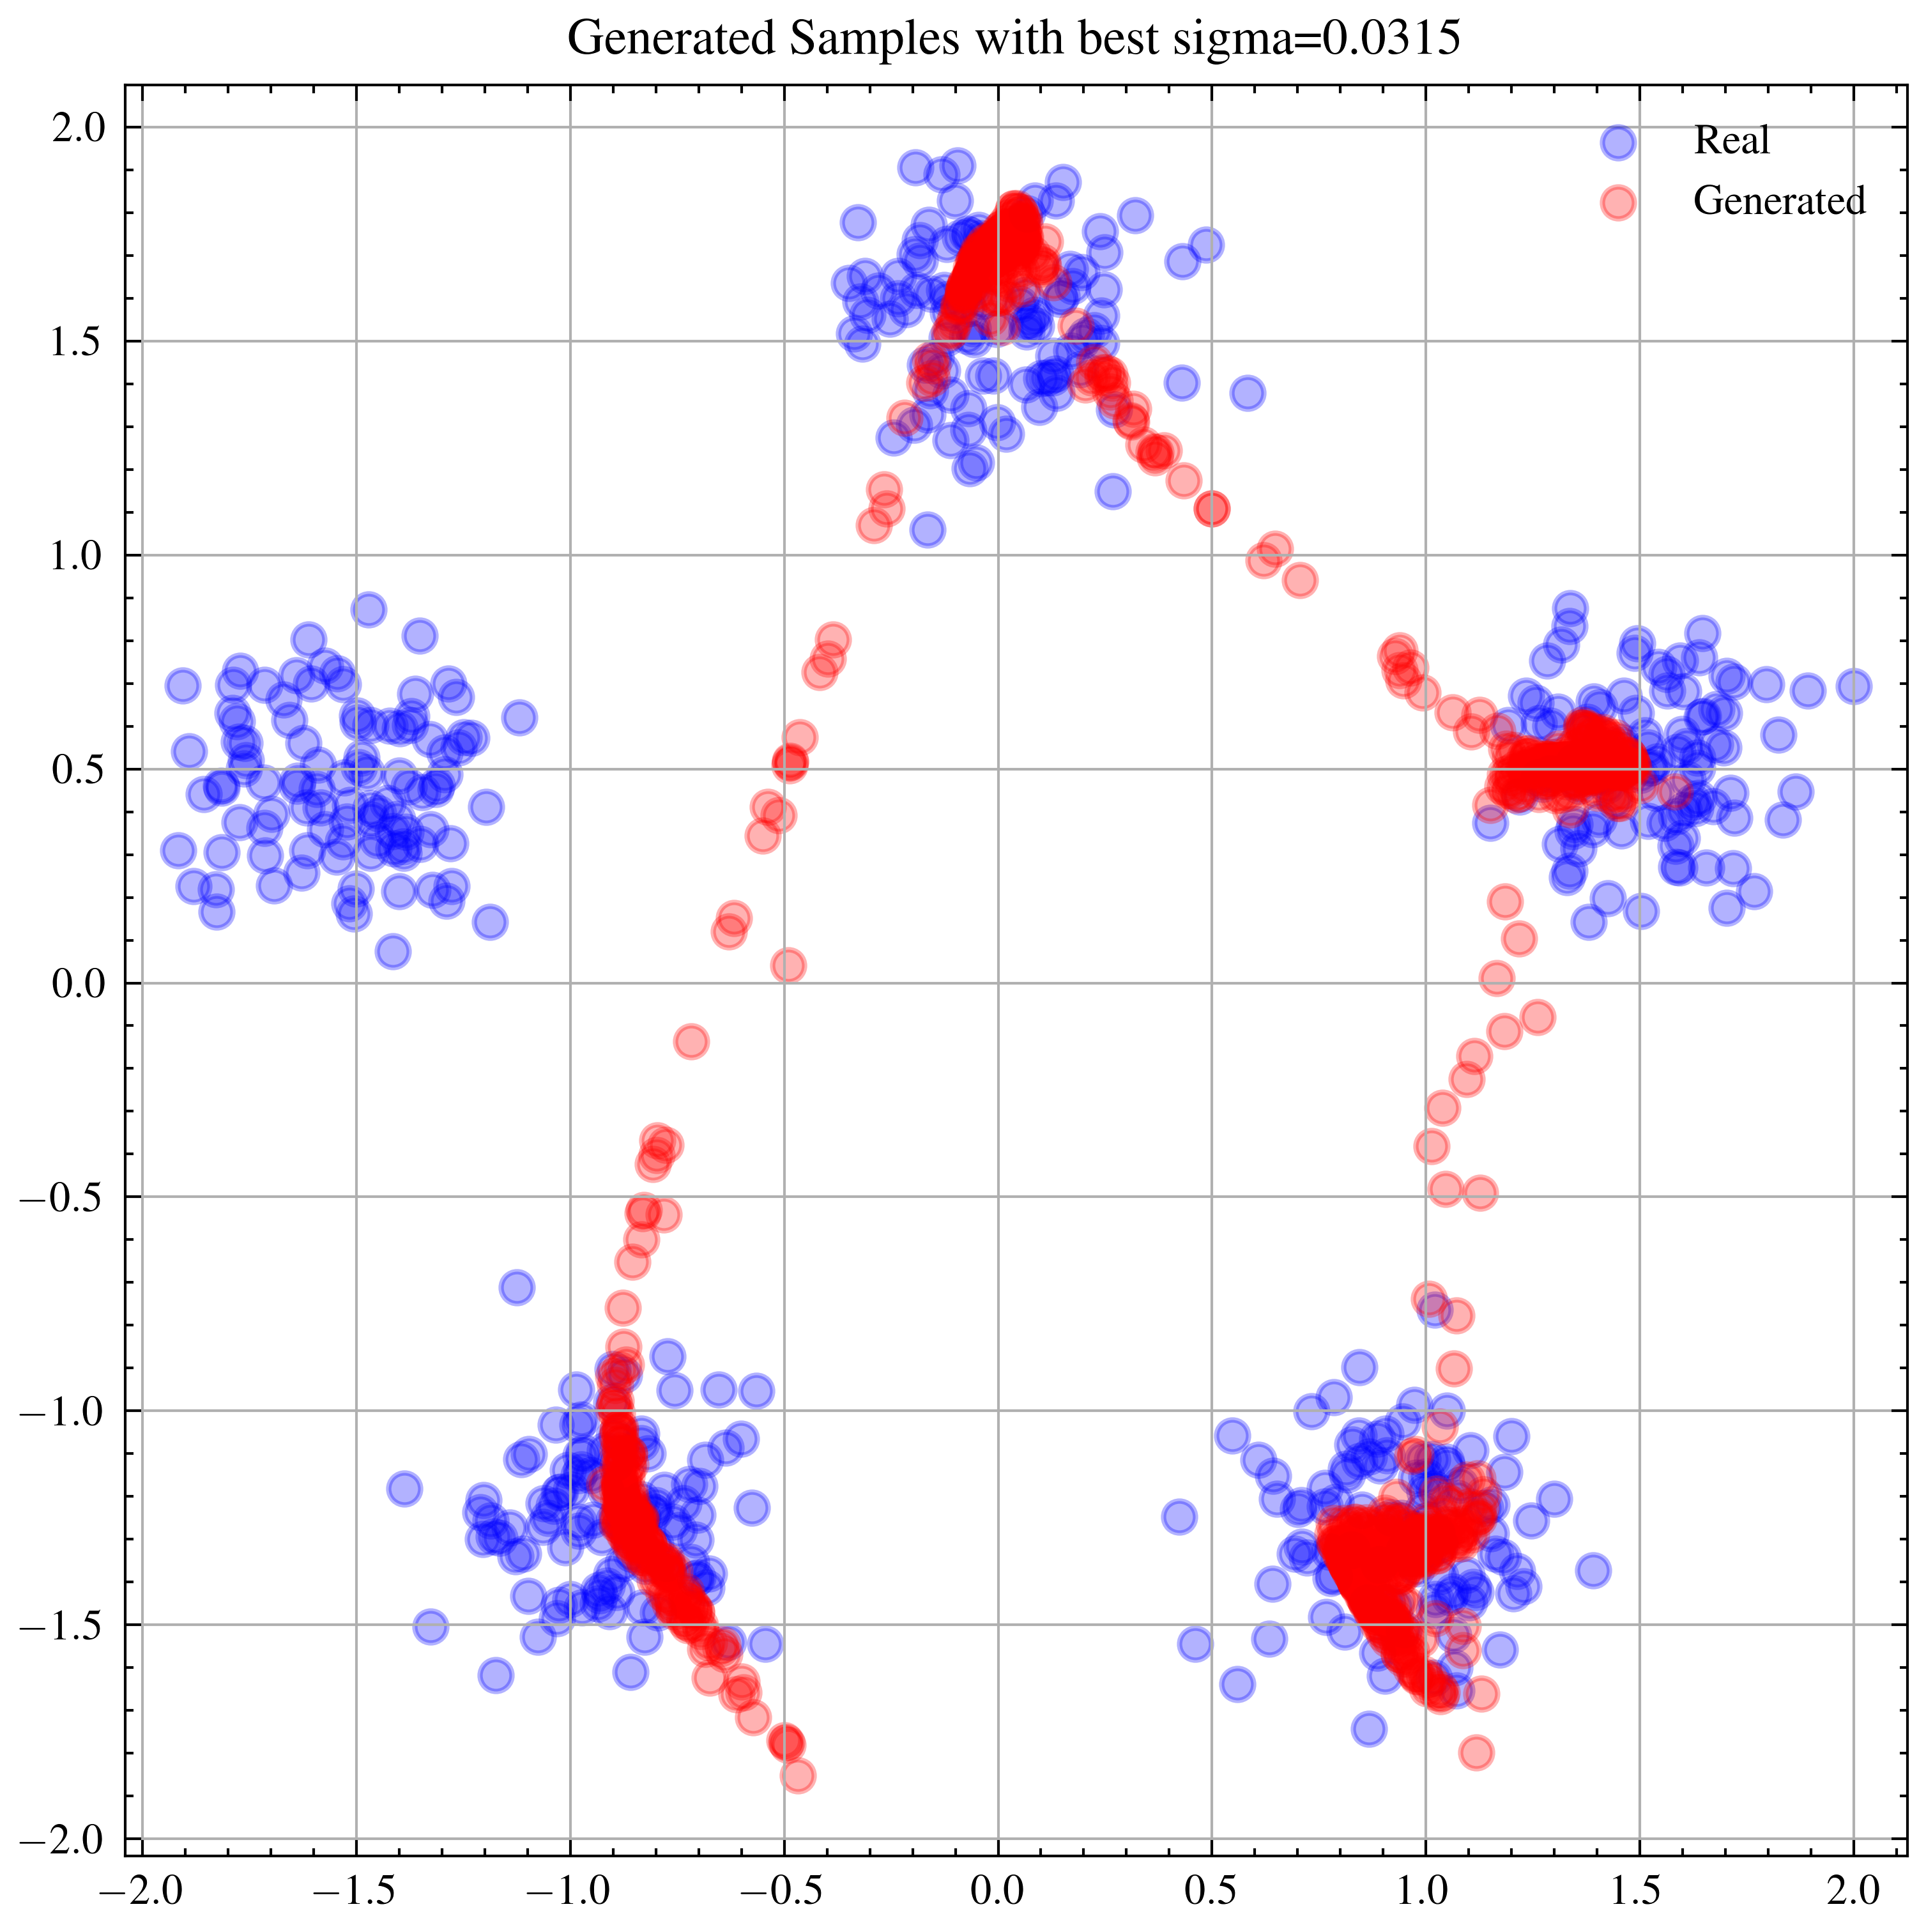

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import optuna
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans # Import KMeans explicitly

# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)

# 数据生成函数
def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        # Use float32 from the start for consistency
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t.astype(np.float32)) # Ensure float32
        y.append(y_t.astype(np.float32)) # Ensure float32

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    # Ensure the final output is float32
    return (train / (np.max(train) * r)).astype(np.float32)

# Generator类
class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)
        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

# Discriminator类（带固定sigma）
class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, fixed_sigma):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # 使用固定的sigma值（不再是可学习参数）
        self.fixed_sigma = fixed_sigma

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)  # Logits

        sigma = self.fixed_sigma
        scaled_output = d_y4 / sigma

        output = self.sigmoid(scaled_output)

        return output, d_y4, sigma

# 损失函数
def discriminator_loss(d_real, d_fake):
    d_loss_real = -torch.mean(torch.log(d_real.clamp(min=1e-8)))
    d_loss_fake = -torch.mean(torch.log(1 - d_fake.clamp(max=1-1e-8)))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    return -torch.mean(torch.log(d_fake.clamp(min=1e-8)))

# 评估生成样本的覆盖率和质量
def evaluate_generator_efficient(real_data, gen_samples, n_clusters=5):
    """
    为多模态分布优化的高效评估函数
    """
    # Ensure both inputs are float32 NumPy arrays
    real_data = real_data.astype(np.float32)
    gen_samples = gen_samples.astype(np.float32)

    # 1. 一次性计算K-means聚类
    # Added n_init explicitly to suppress future warning in newer sklearn versions
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    real_cluster_labels = kmeans.fit_predict(real_data)
    cluster_centers = kmeans.cluster_centers_

    # 2. 为生成样本分配聚类
    gen_cluster_assignments = kmeans.predict(gen_samples)

    # 3. 快速计算模态覆盖率
    coverage_scores = []
    for i in range(n_clusters):
        # 计算真实数据和生成数据在各个聚类中的比例
        real_ratio = np.mean(real_cluster_labels == i)
        gen_ratio = np.mean(gen_cluster_assignments == i)

        # 如果有真实数据点在这个聚类，评估覆盖情况
        if real_ratio > 0:
            # 覆盖评分：生成数据占比与真实数据占比的比较
            # 如果生成数据比例至少达到真实数据比例的一定阈值，视为良好覆盖
            # Using a simple ratio for now, could be improved
            coverage = min(gen_ratio / (real_ratio + 1e-10), 1.0) # clamp at 1.0
            # A simple threshold check could also be used, e.g., if gen_ratio > 0.1 * real_ratio
            # For simplicity, we just use the ratio comparison.
            coverage_scores.append(coverage)

    # 4. 计算样本质量（仍使用原来的方法，但只计算随机子集以提高速度）
    # 随机抽样以加速
    sample_size = min(500, len(gen_samples), len(real_data)) # Increased sample size slightly
    real_sample_indices = np.random.choice(len(real_data), sample_size, replace=False)
    gen_sample_indices = np.random.choice(len(gen_samples), sample_size, replace=False)

    real_sample = real_data[real_sample_indices]
    gen_sample = gen_samples[gen_sample_indices]

    # 计算距离矩阵 (cdist already handles float32)
    distance_matrix = cdist(gen_sample, real_sample)

    # 每个生成样本到最近真实样本的距离
    min_distances = np.min(distance_matrix, axis=1)
    sample_quality = np.mean(min_distances) # Lower is better

    # 5. 模态覆盖率 (Average coverage score across modes with real data)
    mode_coverage = np.mean(coverage_scores) if coverage_scores else 0.0 # Average of the coverage ratios

    # 6. 简化的综合得分
    # Combine coverage and quality. Higher coverage and lower quality score are better.
    # We want to maximize this score.
    # A simple combination could be coverage * (1 / (1 + quality)) or coverage - quality (if scales are similar)
    # Let's use coverage / (1 + quality) as quality is a distance (always non-negative)
    # We can also scale quality if needed, but for this problem, it might be okay.
    # Another option: Use a sigmoid-like function for quality: coverage * (2 / (1 + exp(quality))) - 1
    # Let's stick to a simpler form first: coverage * (1 / (1 + quality))
    # This penalizes high quality values.

    # Let's reconsider the score. We want high coverage and low quality.
    # Maybe quality should contribute negatively or inversely.
    # Option 1: Mode Coverage - Sample Quality (if quality is on a comparable scale)
    # Option 2: Mode Coverage * (Constant / Sample Quality) - might be unstable if quality is near zero
    # Option 3: Mode Coverage * exp(-Sample Quality / Scale)
    # Option 4: Mode Coverage * (1 - tanh(Sample Quality / Scale))

    # Let's try a slightly modified combined score that gives weight to both.
    # Maximize: alpha * Mode Coverage - beta * Sample Quality
    # For simplicity, let's use a proportional approach based on the scales observed.
    # Quality is a distance, coverage is a ratio [0, 1].
    # Let's try to scale quality roughly to the same range.
    # Maximize: Mode Coverage - scaled_quality
    # A simple scaling of quality could be dividing by its typical range, but that's hard to know apriori.
    # Let's go back to the inverse idea but make it more robust:
    # Maximize: Mode Coverage * (1 / (1 + Sample Quality)) - this is what was there, let's refine the logic.
    # This score is higher when coverage is high and quality is low. It makes sense.

    # Let's add a small constant to quality in the denominator to avoid division by near zero.
    combined_score = mode_coverage / (1.0 + sample_quality + 1e-8) # Add small epsilon

    return mode_coverage, sample_quality, combined_score

# Optuna优化目标函数
def objective(trial):
    # 超参数设置
    nb_neurons_h1 = 16
    nb_neurons_h2 = 16
    nb_neurons_h3 = 16
    learning_rate = 5e-5
    batch_size = 32
    z_dim = 2
    x_dim = 2
    epochs = 500  # Reduced epochs for faster hyperparameter search

    # 从Optuna中获取sigma值
    sigma = trial.suggest_float('sigma', 0.01, 1.0, log=True) # Expanded range

    # 创建模型
    generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
    discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, fixed_sigma=sigma)

    # 优化器
    g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

    # 数据准备
    X_train = genGauss(100, 5, 0.5) # genGauss now returns float32
    X_train_tensor = torch.Tensor(X_train).float() # Ensure tensor is float32
    indices = torch.randperm(X_train_tensor.size(0))
    X_train_tensor = X_train_tensor[indices]

    # 训练循环
    for epoch in range(epochs):
        batch_discriminator_loss = []
        batch_generator_loss = []

        nb_batches = int(X_train_tensor.shape[0] / batch_size)

        for i in range(nb_batches):
            image_batch = X_train_tensor[i * batch_size:(i + 1) * batch_size]

            # Train discriminator
            d_optimizer.zero_grad()
            d_real, _, _ = discriminator(image_batch)
            z_input = torch.randn(batch_size, z_dim)
            fake_img = generator(z_input).detach()
            d_fake, _, _ = discriminator(fake_img)
            d_loss = discriminator_loss(d_real, d_fake)
            d_loss.backward()
            d_optimizer.step()

            # Train generator
            g_optimizer.zero_grad()
            z_input = torch.randn(batch_size, z_dim)
            fake_img_for_g = generator(z_input)
            d_fake_for_g, _, _ = discriminator(fake_img_for_g)
            g_loss = generator_loss(d_fake_for_g)
            g_loss.backward()
            g_optimizer.step()

            batch_discriminator_loss.append(d_loss.item())
            batch_generator_loss.append(g_loss.item())

        avg_d_loss = np.mean(batch_discriminator_loss)
        avg_g_loss = np.mean(batch_generator_loss)

        # Report state for pruning (report generator loss)
        trial.report(avg_g_loss, epoch)

        # Handle trial's early stopping
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()


    # Evaluate final generated samples after training for this trial
    with torch.no_grad():
        # Ensure generated samples are float32 NumPy arrays
        gen_samples = generator(torch.randn(1000, z_dim)).detach().cpu().numpy().astype(np.float32)

    # Calculate evaluation metrics
    # Pass the original X_train numpy array (which is now float32)
    mode_coverage, sample_quality, combined_score = evaluate_generator_efficient(X_train, gen_samples, n_clusters=5)


    # Print result for each trial
    print(f"Trial {trial.number}: Sigma={sigma:.4f}, Mode Coverage={mode_coverage:.4f}, "
          f"Sample Quality={sample_quality:.4f}, Score={combined_score:.4f}")

    # Return combined score as the optimization objective
    return combined_score

# 主函数
def main():
    # 创建Optuna的学习器
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=seed), # Use the global seed
                                pruner=optuna.pruners.MedianPruner()) # Add a pruner

    # 运行优化
    print("Starting Optuna optimization...")
    # Increased trials
    study.optimize(objective, n_trials=50, show_progress_bar=True)


    # 打印最佳结果
    print("\nBest trial:")
    trial = study.best_trial
    print(f"  Value (Combined Score): {trial.value:.4f}")
    print(f"  Best Sigma: {trial.params['sigma']:.4f}")

    # 使用最佳sigma训练完整模型并评估
    best_sigma = trial.params['sigma']
    print(f"\nTraining final model with best sigma = {best_sigma}")

    # Train final model with more epochs
    train_and_evaluate_final_model(best_sigma)

def train_and_evaluate_final_model(best_sigma):
    # Hyperparameter settings (same as objective, but potentially more epochs)
    nb_neurons_h1 = 16
    nb_neurons_h2 = 16
    nb_neurons_h3 = 16
    learning_rate = 5e-5
    batch_size = 32
    z_dim = 2
    x_dim = 2
    epochs = 5000  # Use more epochs for full training

    # Create models
    generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
    discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, fixed_sigma=best_sigma)

    # Optimizers
    g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

    # Data preparation (ensure float32)
    X_train = genGauss(100, 5, 0.5)
    X_train_tensor = torch.Tensor(X_train).float()
    indices = torch.randperm(X_train_tensor.size(0))
    X_train_tensor = X_train_tensor[indices]

    # Training loop
    print(f"Training for {epochs} epochs...")
    for epoch in range(epochs):
        nb_batches = int(X_train_tensor.shape[0] / batch_size)
        d_losses = []
        g_losses = []
        for i in range(nb_batches):
            image_batch = X_train_tensor[i * batch_size:(i + 1) * batch_size]

            # Train discriminator
            d_optimizer.zero_grad()
            d_real, _, _ = discriminator(image_batch)
            z_input = torch.randn(batch_size, z_dim)
            fake_img = generator(z_input).detach()
            d_fake, _, _ = discriminator(fake_img)
            d_loss = discriminator_loss(d_real, d_fake)
            d_loss.backward()
            d_optimizer.step()

            # Train generator
            g_optimizer.zero_grad()
            z_input = torch.randn(batch_size, z_dim)
            fake_img_for_g = generator(z_input)
            d_fake_for_g, _, _ = discriminator(fake_img_for_g)
            g_loss = generator_loss(d_fake_for_g)
            g_loss.backward()
            g_optimizer.step()

            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())


        # Print training info every 500 epochs
        if (epoch + 1) % 500 == 0:
             print(f"Epoch {epoch + 1}/{epochs}, Avg D Loss: {np.mean(d_losses):.4f}, Avg G Loss: {np.mean(g_losses):.4f}")

    # Final evaluation of the model
    with torch.no_grad():
        # Ensure generated samples are float32 NumPy arrays
        gen_samples = generator(torch.randn(1000, z_dim)).numpy().astype(np.float32)

    # Calculate evaluation metrics
    mode_coverage, sample_quality, combined_score = evaluate_generator_efficient(X_train, gen_samples, n_clusters=5)

    print("\nFinal Evaluation:")
    print(f"  Mode Coverage: {mode_coverage:.4f}")
    print(f"  Sample Quality (lower is better): {sample_quality:.4f}")
    print(f"  Combined Score: {combined_score:.4f}")

    # Visualize generated vs real samples
    plt.figure(figsize=(6, 6))
    plt.scatter(X_train[:, 0], X_train[:, 1], c='blue', alpha=0.3, label='Real')
    plt.scatter(gen_samples[:, 0], gen_samples[:, 1], c='red', alpha=0.3, label='Generated')
    plt.legend()
    plt.title(f"Generated Samples with best sigma={best_sigma:.4f}")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

# Launch main function
if __name__ == '__main__':
    main()

[I 2025-04-23 15:14:26,738] A new study created in memory with name: no-name-76a935da-dbf6-453a-a7d8-76e81d315425


Starting Optuna optimization...


  0%|          | 0/50 [00:00<?, ?it/s]

Trial 0: Sigma=0.0221, Mode Coverage=0.2000, Sample Quality=0.0378, Imbalance=1.6000, Score=-1.5711
[I 2025-04-23 15:16:25,412] Trial 0 finished with value: -1.5710703256963328 and parameters: {'sigma': 0.022056450893696126}. Best is trial 0 with value: -1.5710703256963328.
Trial 1: Sigma=0.2152, Mode Coverage=0.6600, Sample Quality=0.1770, Imbalance=0.5340, Score=-0.7063
[I 2025-04-23 15:18:24,775] Trial 1 finished with value: -0.7063261710639174 and parameters: {'sigma': 0.21523993209327044}. Best is trial 1 with value: -0.7063261710639174.
Trial 2: Sigma=0.2898, Mode Coverage=0.9980, Sample Quality=0.0934, Imbalance=0.4380, Score=0.0839
[I 2025-04-23 15:20:21,950] Trial 2 finished with value: 0.08386167108888876 and parameters: {'sigma': 0.2897523434197038}. Best is trial 2 with value: 0.08386167108888876.
Trial 3: Sigma=0.0360, Mode Coverage=0.7980, Sample Quality=0.1001, Imbalance=0.4900, Score=-0.1388
[I 2025-04-23 15:22:19,341] Trial 3 finished with value: -0.1388481901642763 an

d:\anaconda\envs\torch2\lib\site-packages\optuna\pruners\_percentile.py:19: RuntimeWarning: All-NaN slice encountered
  return np.nanmax(values)


[I 2025-04-23 15:30:21,654] Trial 39 pruned. 
[I 2025-04-23 15:30:21,747] Trial 40 pruned. 
[I 2025-04-23 15:30:21,843] Trial 41 pruned. 
[I 2025-04-23 15:30:21,931] Trial 42 pruned. 
Trial 43: Sigma=0.0252, Mode Coverage=0.4000, Sample Quality=0.0387, Imbalance=1.2000, Score=-0.9756
[I 2025-04-23 15:32:15,563] Trial 43 finished with value: -0.9755592009131716 and parameters: {'sigma': 0.025206930825238255}. Best is trial 2 with value: 0.08386167108888876.
[I 2025-04-23 15:32:15,659] Trial 44 pruned. 
[I 2025-04-23 15:32:15,727] Trial 45 pruned. 
[I 2025-04-23 15:32:15,799] Trial 46 pruned. 
[I 2025-04-23 15:32:15,891] Trial 47 pruned. 
[I 2025-04-23 15:32:15,999] Trial 48 pruned. 
[I 2025-04-23 15:32:16,091] Trial 49 pruned. 

Best trial:
  Value (Combined Score): 0.0839
  Best Sigma: 0.2898

Training final model with best sigma = 0.2897523434197038
Training for 5000 epochs...
Epoch 500/5000, Avg D Loss: 1.3184, Avg G Loss: 1.0618
Epoch 1000/5000, Avg D Loss: 0.9747, Avg G Loss: 1.198

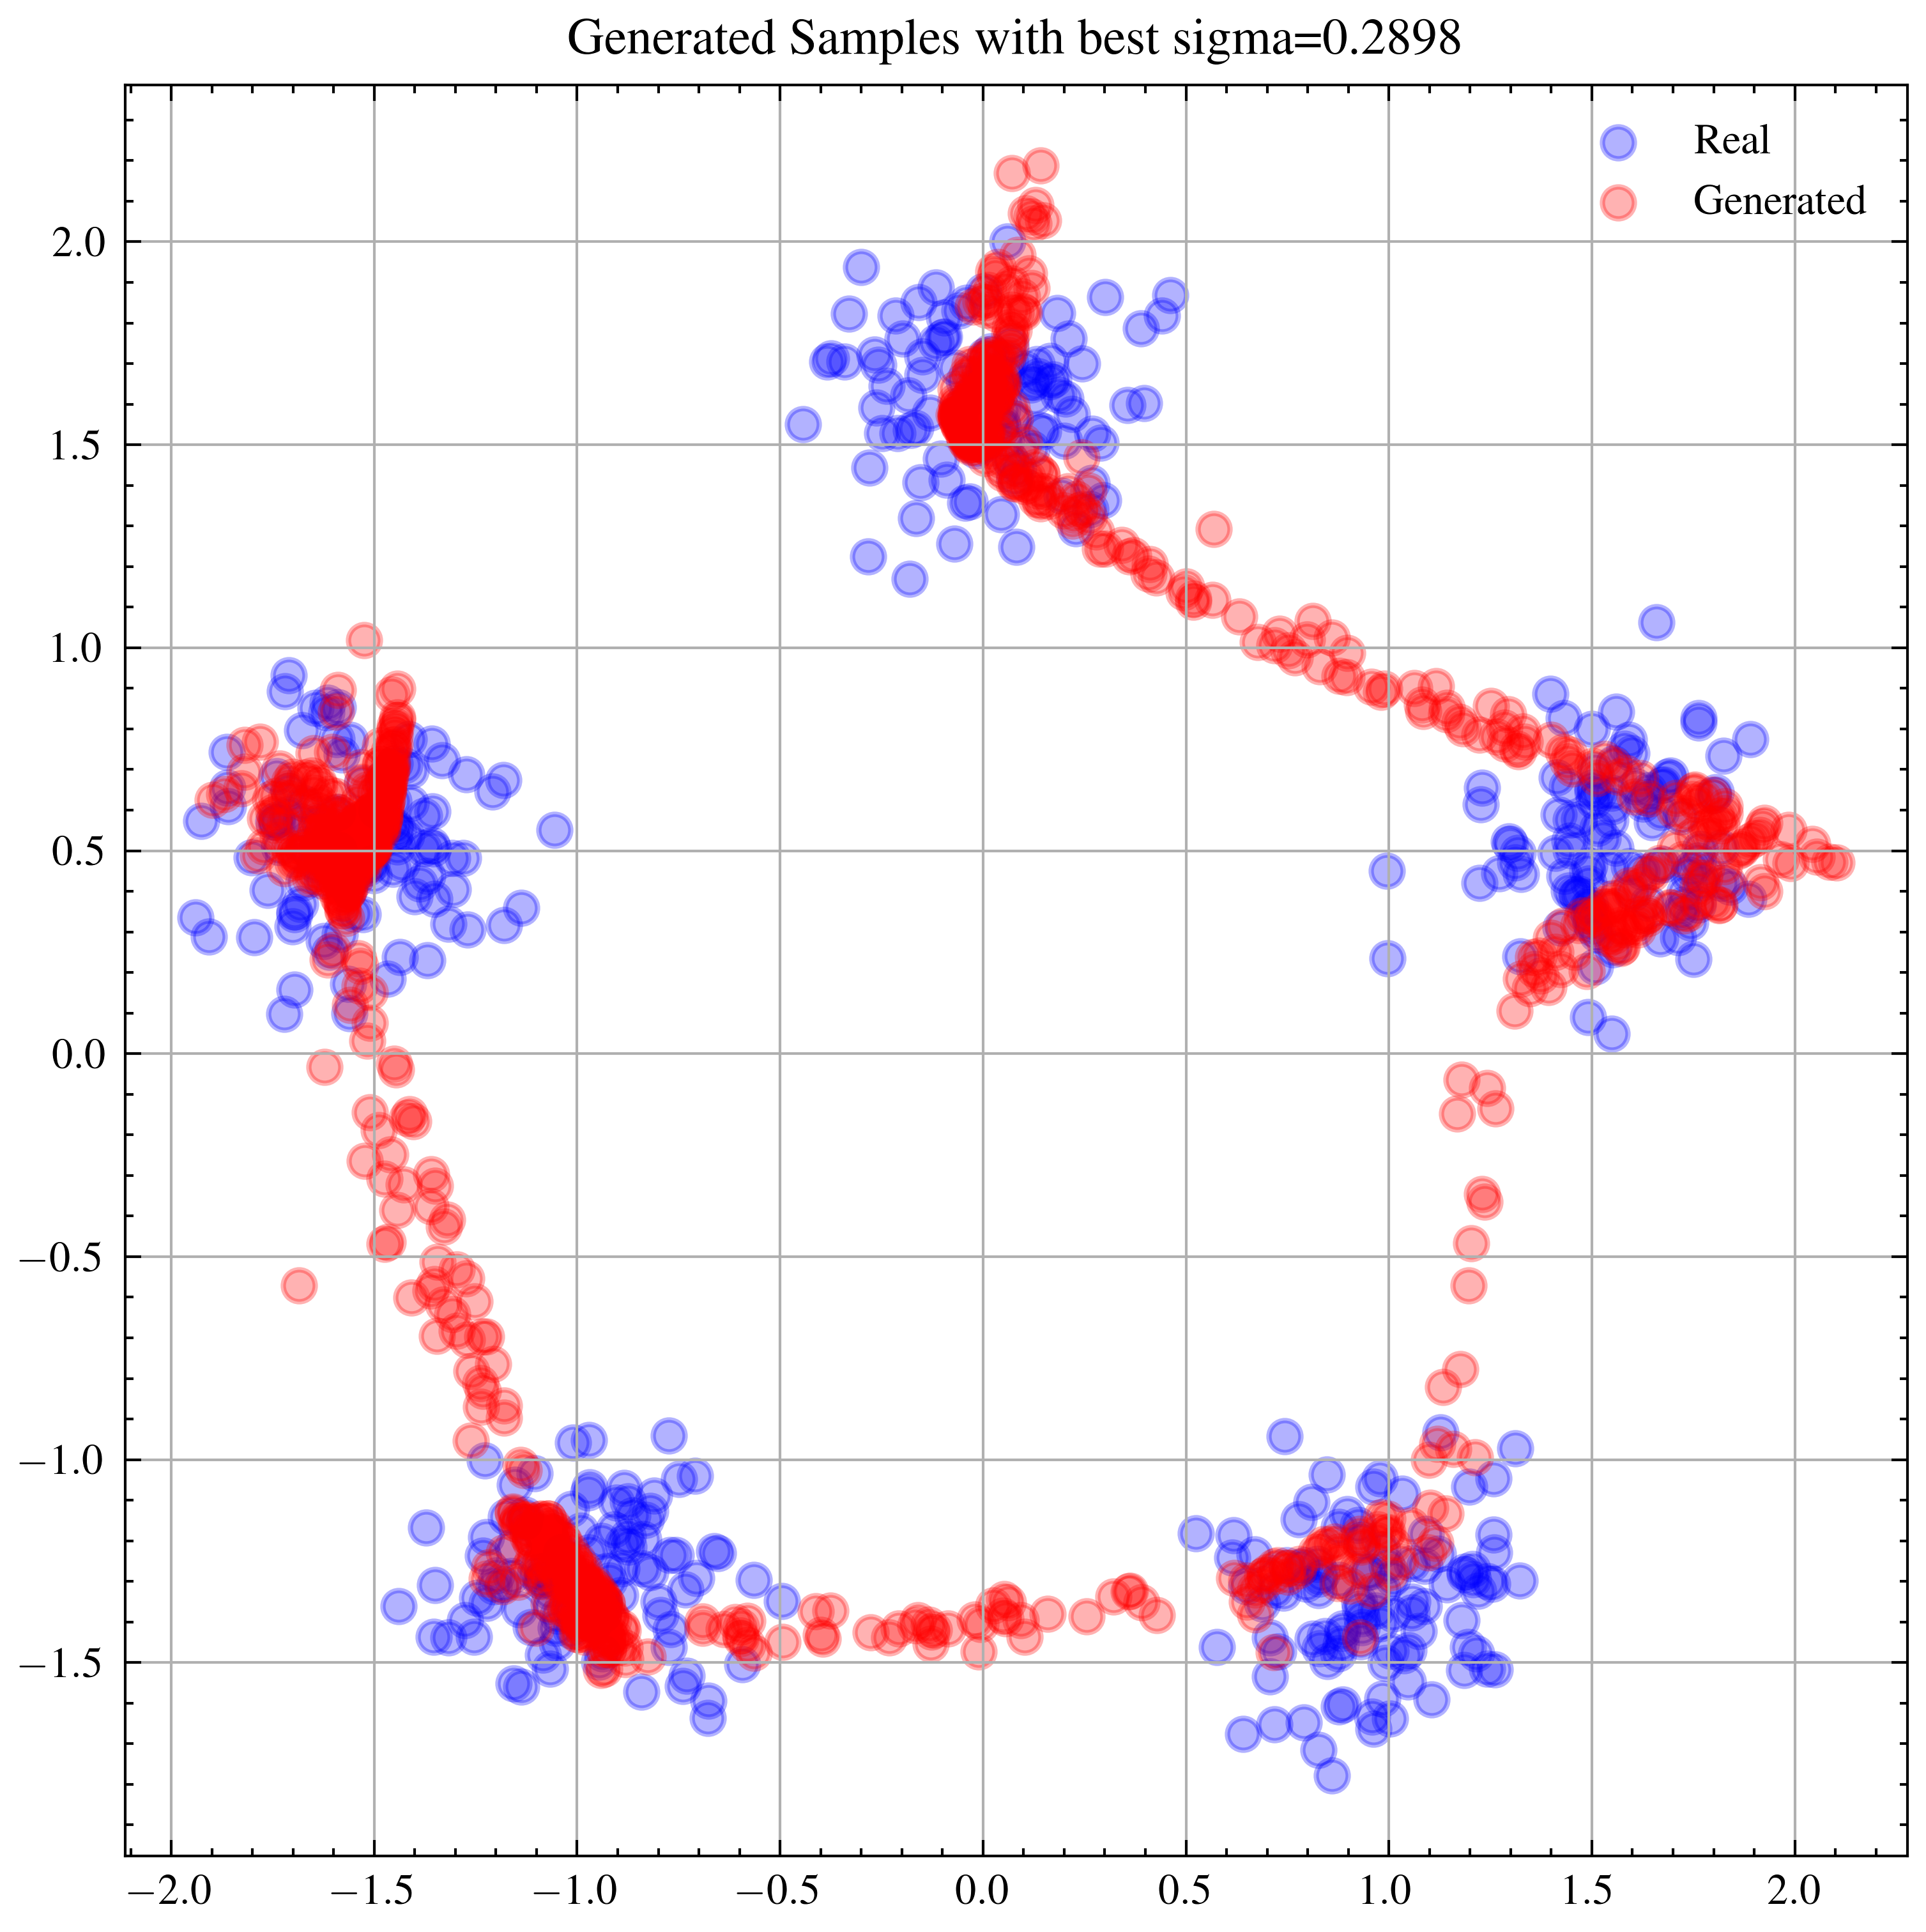

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
import optuna
from sklearn.neighbors import NearestNeighbors
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans # Import KMeans explicitly
import warnings

# Suppress KMeans memory leak warning on Windows
warnings.filterwarnings("ignore", message="KMeans is known to have a memory leak on Windows with MKL")


# 设置随机数种子
seed = 74
torch.manual_seed(seed)
np.random.seed(seed)

# 数据生成函数
def genGauss(p, n=1, r=1):
    x = []
    y = []
    for k in range(n):
        # Use float32 from the start for consistency
        x_t, y_t = np.random.multivariate_normal([math.sin(2*k*math.pi/n), math.cos(2*k*math.pi/n)], [[0.0125, 0], [0, 0.0125]], p).T
        x.append(x_t.astype(np.float32)) # Ensure float32
        y.append(y_t.astype(np.float32)) # Ensure float32

    x = np.array(x).flatten()[:, None]
    y = np.array(y).flatten()[:, None]
    x -= np.mean(x)
    y -= np.mean(y)
    train = np.concatenate((x, y), axis=1)

    # Ensure the final output is float32
    return (train / (np.max(train) * r)).astype(np.float32)

# Generator类
class Generator(nn.Module):
    def __init__(self, z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(z_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, x_dim)
        self.relu = nn.ReLU()

    def forward(self, z_input):
        g_y1 = self.relu(self.fc1(z_input))
        g_y2 = self.relu(self.fc2(g_y1))
        g_y3 = self.relu(self.fc3(g_y2))
        g_y4 = self.fc4(g_y3)
        return g_y4

# Discriminator类（带固定sigma）
class Discriminator(nn.Module):
    def __init__(self, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, fixed_sigma):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(x_dim, nb_neurons_h1)
        self.fc2 = nn.Linear(nb_neurons_h1, nb_neurons_h2)
        self.fc3 = nn.Linear(nb_neurons_h2, nb_neurons_h3)
        self.fc4 = nn.Linear(nb_neurons_h3, 1)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

        # 使用固定的sigma值（不再是可学习参数）
        self.fixed_sigma = fixed_sigma

    def forward(self, x_input):
        d_y1 = self.relu(self.fc1(x_input))
        d_y2 = self.relu(self.fc2(d_y1))
        d_y3 = self.relu(self.fc3(d_y2))
        d_y4 = self.fc4(d_y3)  # Logits

        sigma = self.fixed_sigma
        # Add small epsilon to sigma to prevent division by zero or very small numbers
        scaled_output = d_y4 / (sigma + 1e-8)

        output = self.sigmoid(scaled_output)

        return output, d_y4, sigma

# 损失函数
def discriminator_loss(d_real, d_fake):
    d_loss_real = -torch.mean(torch.log(d_real.clamp(min=1e-8)))
    d_loss_fake = -torch.mean(torch.log(1 - d_fake.clamp(max=1-1e-8)))
    return d_loss_real + d_loss_fake

def generator_loss(d_fake):
    return -torch.mean(torch.log(d_fake.clamp(min=1e-8)))

# 评估生成样本的覆盖率和质量 (改进版)
def evaluate_generator_efficient(real_data, gen_samples, n_clusters=5, adaptive_threshold_factor=2.0):
    """
    改进的评估函数，考虑模态覆盖率（带自适应阈值）、样本质量和模态平衡。
    """
    # Ensure both inputs are float32 NumPy arrays
    real_data = real_data.astype(np.float32)
    gen_samples = gen_samples.astype(np.float32)

    if len(gen_samples) == 0:
        # Handle case where generator produces no samples
        return 0.0, np.inf, np.inf, 1e-8 # coverage, quality, imbalance, combined_score

    # 1. K-means聚类识别真实数据模态
    try:
        # Added n_init='auto' explicitly
        kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
        real_cluster_labels = kmeans.fit_predict(real_data)
        cluster_centers = kmeans.cluster_centers_
    except ValueError:
        # Handle cases where KMeans might fail (e.g., not enough points)
        print("Warning: KMeans failed. Returning poor evaluation scores.")
        return 0.0, np.inf, np.inf, 1e-8

    # Calculate standard deviation for each real cluster
    cluster_stds = []
    real_points_by_cluster = []
    for i in range(n_clusters):
        real_points_in_cluster = real_data[real_cluster_labels == i]
        real_points_by_cluster.append(real_points_in_cluster)
        if len(real_points_in_cluster) > 1:
            # Use np.std for multi-dimensional data, calculates std independently for each dimension
            # Or calculate the average distance from points to cluster center and use that as a scale
            # Let's use the average distance to the center as a scale
             distances_to_center = np.linalg.norm(real_points_in_cluster - cluster_centers[i], axis=1)
             cluster_stds.append(np.mean(distances_to_center)) # Using mean distance as scale
            # Alternative: np.mean(np.std(real_points_in_cluster, axis=0)) # Average of std per dimension
        else:
            cluster_stds.append(1e-8) # Avoid division by zero

    mean_cluster_std = np.mean(cluster_stds) if cluster_stds else 1e-8


    # 2. 样本质量 (Mean distance from generated to nearest real)
    # Use sampling for efficiency
    sample_size_quality = min(1000, len(gen_samples), len(real_data)) # Increased sample size for quality
    gen_sample_indices = np.random.choice(len(gen_samples), sample_size_quality, replace=False)
    real_sample_indices_quality = np.random.choice(len(real_data), sample_size_quality, replace=False)

    gen_sample_quality = gen_samples[gen_sample_indices]
    real_sample_quality = real_data[real_sample_indices_quality]

    if len(gen_sample_quality) > 0 and len(real_sample_quality) > 0:
        distance_matrix_quality = cdist(gen_sample_quality, real_sample_quality)
        min_distances_quality = np.min(distance_matrix_quality, axis=1)
        sample_quality = np.mean(min_distances_quality) # Lower is better
    else:
        sample_quality = np.inf


    # 3. 模态平衡 (Compare proportions of points in each cluster)
    # Assign generated points to real clusters based on nearest center
    gen_cluster_assignments = kmeans.predict(gen_samples)

    real_proportions = np.bincount(real_cluster_labels, minlength=n_clusters).astype(np.float32) / len(real_data)
    gen_proportions = np.bincount(gen_cluster_assignments, minlength=n_clusters).astype(np.float32) / len(gen_samples)

    # Mode Imbalance Penalty (Sum of absolute differences in proportions)
    mode_imbalance_penalty = np.sum(np.abs(gen_proportions - real_proportions)) # Lower is better


    # 4. 模态覆盖率 (Percentage of real points "hit" within adaptive threshold)
    total_covered_real_points = 0
    total_real_points_in_evaluated_clusters = 0

    # Use sampling for calculating coverage efficiently
    sample_size_coverage = min(1000, len(real_data)) # Sample real points for coverage check
    real_sample_indices_coverage = np.random.choice(len(real_data), sample_size_coverage, replace=False)
    real_sample_coverage = real_data[real_sample_indices_coverage]
    real_sample_coverage_labels = real_cluster_labels[real_sample_indices_coverage]


    if len(real_sample_coverage) > 0 and len(gen_samples) > 0:
         # Calculate distances from sampled real points to ALL generated points
        distance_matrix_coverage = cdist(real_sample_coverage, gen_samples)
        distances_to_nearest_gen = np.min(distance_matrix_coverage, axis=1)

        # Calculate coverage based on adaptive threshold for sampled real points
        covered_count_sample = 0
        evaluated_sample_points = 0
        for i, real_point in enumerate(real_sample_coverage):
            cluster_label = real_sample_coverage_labels[i]
            # Get the scale for this point's cluster (using the pre-calculated cluster std/scale)
            cluster_scale = cluster_stds[cluster_label] if cluster_label < len(cluster_stds) else mean_cluster_std # Use mean if somehow index is out of bounds

            if distances_to_nearest_gen[i] < adaptive_threshold_factor * cluster_scale:
                covered_count_sample += 1
            evaluated_sample_points += 1

        mode_coverage = covered_count_sample / (evaluated_sample_points + 1e-8) # Higher is better
    else:
        mode_coverage = 0.0


    # 5. 综合评分
    # Maximize: Mode Coverage - Sample Quality - Mode Imbalance Penalty
    # We need to scale the terms. Let's scale Sample Quality by the average cluster std dev.
    scaled_sample_quality = sample_quality / (mean_cluster_std + 1e-8) if sample_quality != np.inf else np.inf

    # Maximize: Mode Coverage - Scaled Sample Quality - Mode Imbalance Penalty
    # Handle infinite sample quality
    if scaled_sample_quality == np.inf:
         # If sample quality is infinite, it means generated samples are very far from real.
         # The score should be very low.
         combined_score = -np.inf
    else:
        combined_score = mode_coverage - scaled_sample_quality - mode_imbalance_penalty


    # Ensure combined_score is a finite float for Optuna (handle -np.inf)
    if not np.isfinite(combined_score):
         combined_score = -1e9 # Assign a large negative number if infinite


    return mode_coverage, sample_quality, mode_imbalance_penalty, combined_score

# Optuna优化目标函数
def objective(trial):
    # 超参数设置
    nb_neurons_h1 = 16
    nb_neurons_h2 = 16
    nb_neurons_h3 = 16
    learning_rate = 5e-5
    batch_size = 32
    z_dim = 2
    x_dim = 2
    epochs = 2000  # Reduced epochs for faster hyperparameter search

    # 从Optuna中获取sigma值
    sigma = trial.suggest_float('sigma', 0.01, 0.5, log=True) # Expanded range

    # 创建模型
    generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
    discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, fixed_sigma=sigma)

    # 优化器
    g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

    # 数据准备
    X_train = genGauss(100, 5, 0.5) # genGauss now returns float32
    X_train_tensor = torch.Tensor(X_train).float() # Ensure tensor is float32
    indices = torch.randperm(X_train_tensor.size(0))
    X_train_tensor = X_train_tensor[indices]

    # Training loop
    for epoch in range(epochs):
        batch_discriminator_loss = []
        batch_generator_loss = []

        nb_batches = int(X_train_tensor.shape[0] / batch_size)

        for i in range(nb_batches):
            image_batch = X_train_tensor[i * batch_size:(i + 1) * batch_size]

            # Train discriminator
            d_optimizer.zero_grad()
            d_real, _, _ = discriminator(image_batch)
            z_input = torch.randn(batch_size, z_dim)
            fake_img = generator(z_input).detach()
            d_fake, _, _ = discriminator(fake_img)
            d_loss = discriminator_loss(d_real, d_fake)
            d_loss.backward()
            d_optimizer.step()

            # Train generator
            g_optimizer.zero_grad()
            z_input = torch.randn(batch_size, z_dim)
            fake_img_for_g = generator(z_input)
            d_fake_for_g, _, _ = discriminator(fake_img_for_g)
            g_loss = generator_loss(d_fake_for_g)
            g_loss.backward()
            g_optimizer.step()

            batch_discriminator_loss.append(d_loss.item())
            batch_generator_loss.append(g_loss.item())

        avg_d_loss = np.mean(batch_discriminator_loss)
        avg_g_loss = np.mean(batch_generator_loss)

        # Report state for pruning (report generator loss)
        # Optuna prunes trials that are unlikely to reach the best value.
        # Reporting the generator loss helps the pruner decide.
        trial.report(avg_g_loss, epoch)

        # Handle trial's early stopping
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()


    # Evaluate final generated samples after training for this trial
    with torch.no_grad():
        # Ensure generated samples are float32 NumPy arrays
        gen_samples = generator(torch.randn(1000, z_dim)).detach().cpu().numpy().astype(np.float32)

    # Calculate evaluation metrics
    # Pass the original X_train numpy array (which is now float32)
    mode_coverage, sample_quality, mode_imbalance_penalty, combined_score = evaluate_generator_efficient(X_train, gen_samples, n_clusters=5)


    # Print result for each trial
    print(f"Trial {trial.number}: Sigma={sigma:.4f}, Mode Coverage={mode_coverage:.4f}, "
          f"Sample Quality={sample_quality:.4f}, Imbalance={mode_imbalance_penalty:.4f}, Score={combined_score:.4f}")

    # Return combined score as the optimization objective
    return combined_score

# 主函数
def main():
    # 创建Optuna的学习器
    study = optuna.create_study(direction='maximize',
                                sampler=optuna.samplers.TPESampler(seed=seed), # Use the global seed
                                pruner=optuna.pruners.MedianPruner()) # Add a pruner

    # 运行优化
    print("Starting Optuna optimization...")
    # Increased trials
    study.optimize(objective, n_trials=50, show_progress_bar=True)


    # 打印最佳结果
    print("\nBest trial:")
    trial = study.best_trial
    print(f"  Value (Combined Score): {trial.value:.4f}")
    print(f"  Best Sigma: {trial.params['sigma']:.4f}")

    # 使用最佳sigma训练完整模型并评估
    best_sigma = trial.params['sigma']
    print(f"\nTraining final model with best sigma = {best_sigma}")

    # Train final model with more epochs
    train_and_evaluate_final_model(best_sigma)

def train_and_evaluate_final_model(best_sigma):
    # Hyperparameter settings (same as objective, but potentially more epochs)
    nb_neurons_h1 = 16
    nb_neurons_h2 = 16
    nb_neurons_h3 = 16
    learning_rate = 5e-5
    batch_size = 32
    z_dim = 2
    x_dim = 2
    epochs = 5000  # Use more epochs for full training

    # Create models
    generator = Generator(z_dim, x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3)
    discriminator = Discriminator(x_dim, nb_neurons_h1, nb_neurons_h2, nb_neurons_h3, fixed_sigma=best_sigma)

    # Optimizers
    g_optimizer = optim.Adam(generator.parameters(), lr=learning_rate)
    d_optimizer = optim.Adam(discriminator.parameters(), lr=learning_rate)

    # Data preparation (ensure float32)
    X_train = genGauss(100, 5, 0.5)
    X_train_tensor = torch.Tensor(X_train).float()
    indices = torch.randperm(X_train_tensor.size(0))
    X_train_tensor = X_train_tensor[indices]

    # Training loop
    print(f"Training for {epochs} epochs...")
    for epoch in range(epochs):
        nb_batches = int(X_train_tensor.shape[0] / batch_size)
        d_losses = []
        g_losses = []
        for i in range(nb_batches):
            image_batch = X_train_tensor[i * batch_size:(i + 1) * batch_size]

            # Train discriminator
            d_optimizer.zero_grad()
            d_real, _, _ = discriminator(image_batch)
            z_input = torch.randn(batch_size, z_dim)
            fake_img = generator(z_input).detach()
            d_fake, _, _ = discriminator(fake_img)
            d_loss = discriminator_loss(d_real, d_fake)
            d_loss.backward()
            d_optimizer.step()

            # Train generator
            g_optimizer.zero_grad()
            z_input = torch.randn(batch_size, z_dim)
            fake_img_for_g = generator(z_input)
            d_fake_for_g, _, _ = discriminator(fake_img_for_g)
            g_loss = generator_loss(d_fake_for_g)
            g_loss.backward()
            g_optimizer.step()

            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())


        # Print training info every 500 epochs
        if (epoch + 1) % 500 == 0:
             print(f"Epoch {epoch + 1}/{epochs}, Avg D Loss: {np.mean(d_losses):.4f}, Avg G Loss: {np.mean(g_losses):.4f}")

    # Final evaluation of the model
    with torch.no_grad():
        # Ensure generated samples are float32 NumPy arrays
        gen_samples = generator(torch.randn(1000, z_dim)).numpy().astype(np.float32)

    # Calculate evaluation metrics using the improved function
    mode_coverage, sample_quality, mode_imbalance_penalty, combined_score = evaluate_generator_efficient(X_train, gen_samples, n_clusters=5)

    print("\nFinal Evaluation:")
    print(f"  Mode Coverage (higher is better): {mode_coverage:.4f}")
    print(f"  Sample Quality (lower is better): {sample_quality:.4f}")
    print(f"  Mode Imbalance Penalty (lower is better): {mode_imbalance_penalty:.4f}")
    print(f"  Combined Score (higher is better): {combined_score:.4f}")

    # Visualize generated vs real samples
    plt.figure(figsize=(6, 6))
    plt.scatter(X_train[:, 0], X_train[:, 1], c='blue', alpha=0.3, label='Real')
    plt.scatter(gen_samples[:, 0], gen_samples[:, 1], c='red', alpha=0.3, label='Generated')
    plt.legend()
    plt.title(f"Generated Samples with best sigma={best_sigma:.4f}")
    plt.axis("equal")
    plt.grid(True)
    plt.show()

# Launch main function
if __name__ == '__main__':
    main()


Training final model with empirical sigma = 0.1
Training for 5000 epochs...
Epoch 500/5000, Avg D Loss: 0.7701, Avg G Loss: 1.3655
Epoch 1000/5000, Avg D Loss: 0.9892, Avg G Loss: 1.1970
Epoch 1500/5000, Avg D Loss: 1.1255, Avg G Loss: 1.1761
Epoch 2000/5000, Avg D Loss: 1.1973, Avg G Loss: 1.0755
Epoch 2500/5000, Avg D Loss: 1.2413, Avg G Loss: 0.9771
Epoch 3000/5000, Avg D Loss: 1.2068, Avg G Loss: 0.9021
Epoch 3500/5000, Avg D Loss: 1.2356, Avg G Loss: 0.8919
Epoch 4000/5000, Avg D Loss: 1.2316, Avg G Loss: 0.8643
Epoch 4500/5000, Avg D Loss: 1.2795, Avg G Loss: 0.8453
Epoch 5000/5000, Avg D Loss: 1.2688, Avg G Loss: 0.8873

Final Evaluation:
  Mode Coverage (higher is better): 0.9900
  Sample Quality (lower is better): 0.0561
  Mode Imbalance Penalty (lower is better): 0.3680
  Combined Score (higher is better): 0.3516


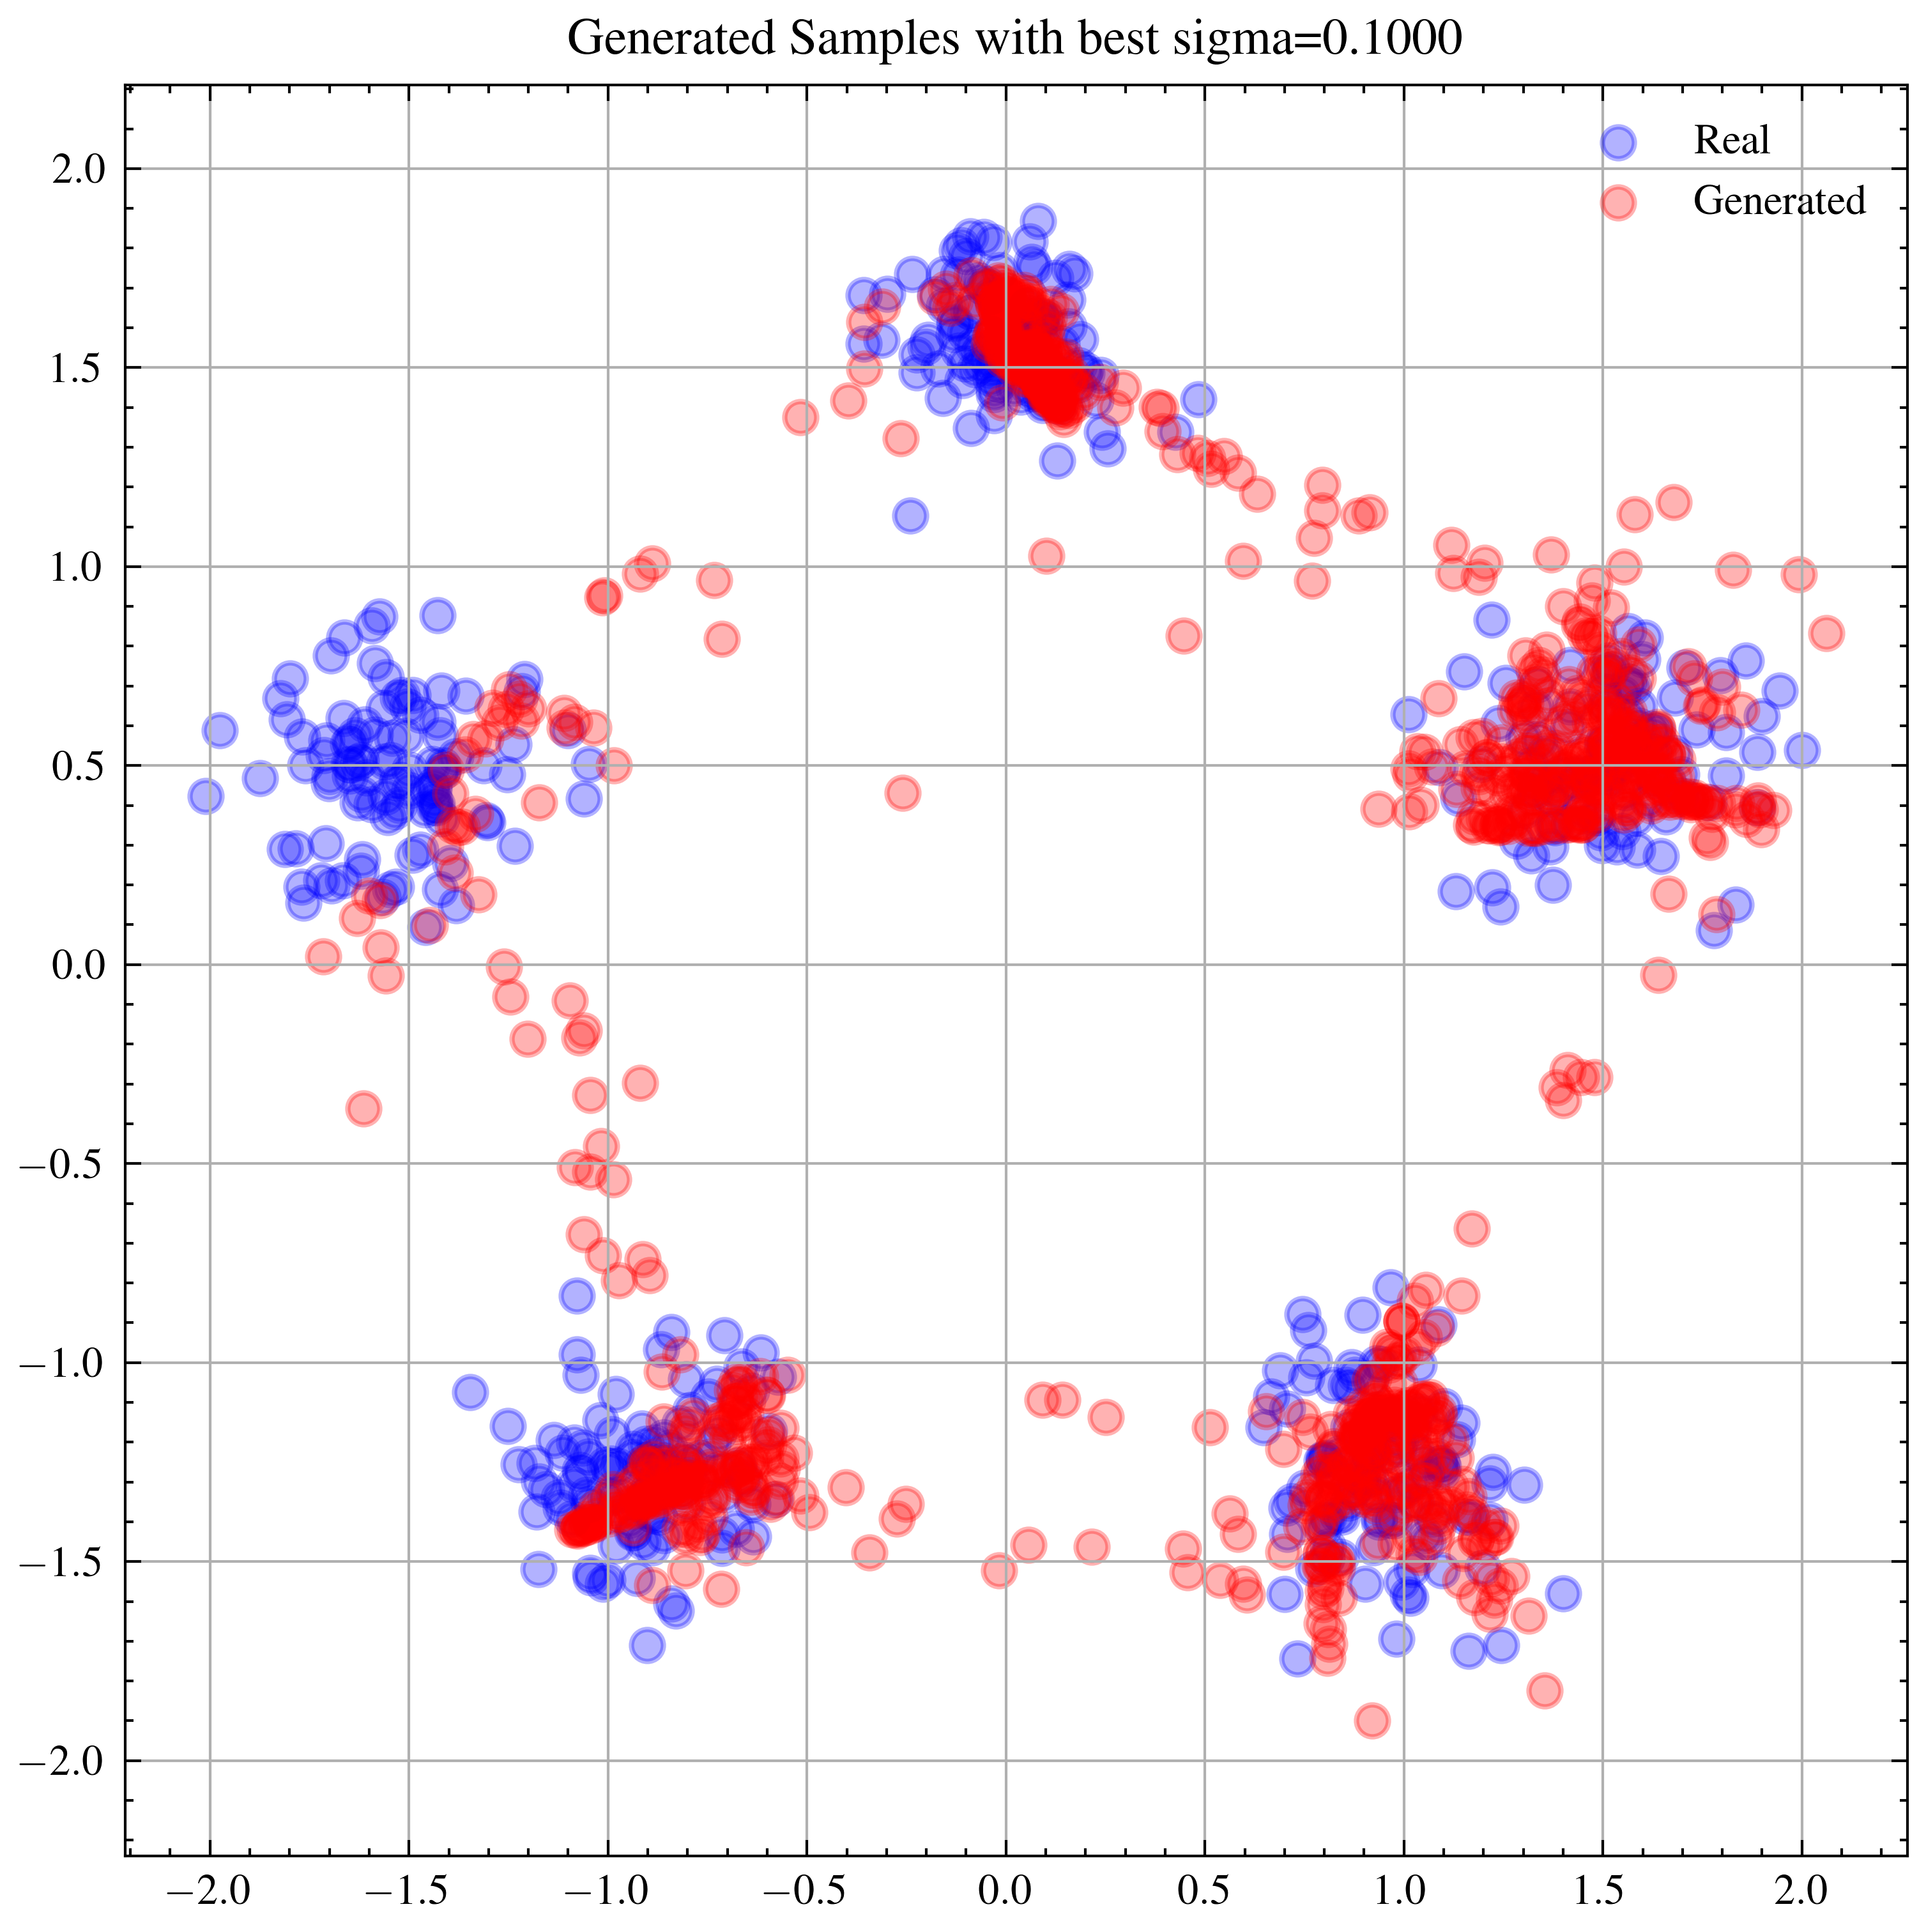

In [17]:
# 主函数 (修改后用于直接评估 sigma=0.1)
def main():
    # # 创建Optuna的学习器 (注释掉 Optuna 部分)
    # study = optuna.create_study(direction='maximize',
    #                             sampler=optuna.samplers.TPESampler(seed=seed), # Use the global seed
    #                             pruner=optuna.pruners.MedianPruner()) # Add a pruner
    #
    # # 运行优化
    # print("Starting Optuna optimization...")
    # # Increased trials
    # study.optimize(objective, n_trials=50, show_progress_bar=True)
    #
    #
    # # 打印最佳结果
    # print("\nBest trial:")
    # trial = study.best_trial
    # print(f"  Value (Combined Score): {trial.value:.4f}")
    # print(f"  Best Sigma: {trial.params['sigma']:.4f}")
    #
    # best_sigma = trial.params['sigma'] # 获取 Optuna 找到的最佳 sigma

    # 直接使用经验值 sigma = 0.1 进行最终模型训练和评估
    empirical_sigma = 0.1
    print(f"\nTraining final model with empirical sigma = {empirical_sigma}")

    # Train final model with more epochs
    train_and_evaluate_final_model(empirical_sigma)


# 启动主函数
if __name__ == '__main__':
    main()